# Data Preparation, initial Analysis and Cleaning
Author: Vasileios Tsoumpris

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import title
import seaborn as sns
from pathlib import Path

from src.visualisations.viz_analysis import (plot_triangular_heatmap,
                                             plot_correlation_column_heatmap,
                                             plot_categorical_stacked)

## Reading file/s (X_train_mini.csv)

In [2]:
root = Path.cwd().parent
dataset_path_Xtrain = \
    root / 'data' / 'interim' / 'split_groupshuffle' / 'X_train_mini.csv'

dataset_path_Ytrain = \
    root / 'data' / 'interim' / 'split_groupshuffle' / 'y_train_mini.csv'

df = pd.read_csv(dataset_path_Xtrain)
df_y = pd.read_csv(dataset_path_Ytrain)
df = pd.concat([df, df_y], axis = "columns")

# rows and columns
print("The dataset contains ", df.shape[0], " rows and ", df.shape[1], " features.")
df.head()

The dataset contains  61211  rows and  49  features.


,encounter_id,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,149190,Caucasian,Female,[10-20),?,1,1,7,3,?,...,No,Up,No,No,No,No,No,Ch,Yes,1
1,64410,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,...,No,No,No,No,No,No,No,No,Yes,0
2,500364,Caucasian,Male,[30-40),?,1,1,7,2,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
3,63768,Caucasian,Male,[70-80),?,1,1,7,5,?,...,No,No,No,No,No,No,No,No,Yes,1
4,15738,Caucasian,Female,[90-100),?,3,3,4,12,?,...,No,Steady,No,No,No,No,No,Ch,Yes,0


## Data Analysis and Initial Cleaning of Data

### Initial Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61211 entries, 0 to 61210
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   encounter_id              61211 non-null  int64
 1   race                      61211 non-null  str  
 2   gender                    61211 non-null  str  
 3   age                       61211 non-null  str  
 4   weight                    61211 non-null  str  
 5   admission_type_id         61211 non-null  int64
 6   discharge_disposition_id  61211 non-null  int64
 7   admission_source_id       61211 non-null  int64
 8   time_in_hospital          61211 non-null  int64
 9   payer_code                61211 non-null  str  
 10  medical_specialty         61211 non-null  str  
 11  num_lab_procedures        61211 non-null  int64
 12  num_procedures            61211 non-null  int64
 13  num_medications           61211 non-null  int64
 14  number_outpatient         61211 non-null  int64
 

**max_glu_serum** and **A1Cresult** have many **Nan** values. We should address them as they may be important for predicting the outcome.

### 1. Is there any encounter_id that is repeated?

In [4]:
# the question is:
# Any patient who has readmitted multiple times?
df["encounter_id"].duplicated(keep = False).unique()

array([False])

Only one unique value (False) indicating that there are no duplicate encounter_ids.

### 2. Is there any patient who has readmitted multiple times?

Important In split_groupshuffle version, there are no patients who have readmitted multiple times. This version drops the feature: patient_nbr

In [5]:
if "patient_nbr" in df.columns:
    print("Distinct number of patients: ",
          df["patient_nbr"].value_counts().shape[0])
    print("Example of patients who have readmitted multiple times:\n",
          df["patient_nbr"].value_counts().head(10))

else: print("No patients who have readmitted multiple times in this split version.")

No patients who have readmitted multiple times in this split version.


### 3. How many unique values in demographic features are there?
(features: gender, race, age)

Function used

In [6]:
def analyse_unique_values(dfr, column_name, plot_bar = True):
    """ Analyse unique values and NAs in a feature."""

    # count the number of unique values in the feature
    analysis_df = dfr[[column_name]].groupby(column_name).size().sort_values(ascending=False)
    # draft a plot of the number of unique values (horizontal bar chart)
    if plot_bar:
        analysis_df.plot(kind = 'barh',
                         title = f'Number of encounters {column_name}',
                         xlabel = 'Count of instances',
                         )
    # identify any NA values
    # find any NA values in the feature,
    # and if exist return True, else False
    has_na = dfr[column_name].isna().any()
    # count the number of NA values
    count_na = dfr[column_name].isna().sum()
    # print the results for NA analysis
    print(f'NAs identified in feature:'
          f'{column_name} with a count of {count_na}' if has_na
          else f'No NAs identified in {column_name} (count = {count_na})' ,)

    print(analysis_df)

    return analysis_df

#### Race

No NAs identified in race (count = 0)
race
Caucasian          45839
AfricanAmerican    11585
?                   1361
Hispanic            1125
Other                892
Asian                409
dtype: int64


race
Caucasian          45839
AfricanAmerican    11585
?                   1361
Hispanic            1125
Other                892
Asian                409
dtype: int64

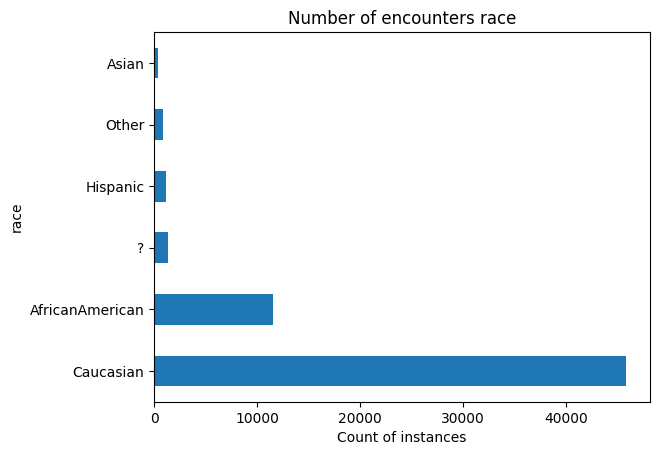

In [7]:
analyse_unique_values(dfr = df, column_name = 'race')

Found the '?' which is likely a placeholder for missing data. How should we handle this?

A possible strategy is to convert to 'Unknown'.

#### Gender

No NAs identified in gender (count = 0)
gender
Female             32989
Male               28221
Unknown/Invalid        1
dtype: int64


gender
Female             32989
Male               28221
Unknown/Invalid        1
dtype: int64

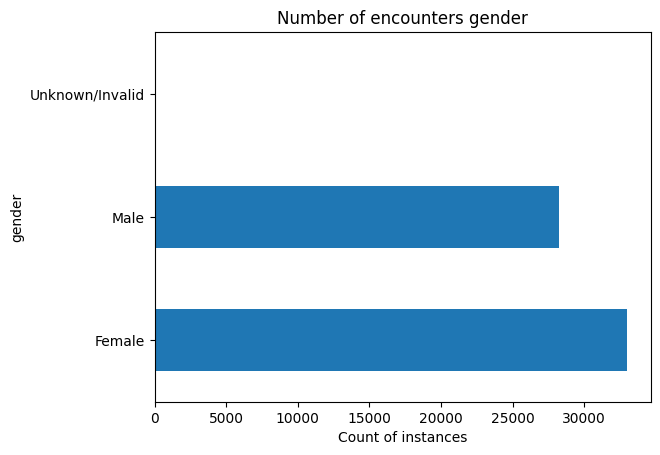

In [8]:
analyse_unique_values(dfr = df, column_name = 'gender')

An imputation strategy is possible for **gender** feature.

#### Age

No NAs identified in age (count = 0)
age
[70-80)     15642
[60-70)     13485
[80-90)     10423
[50-60)     10389
[40-50)      5792
[30-40)      2293
[90-100)     1700
[20-30)       966
[10-20)       428
[0-10)         93
dtype: int64


age
[70-80)     15642
[60-70)     13485
[80-90)     10423
[50-60)     10389
[40-50)      5792
[30-40)      2293
[90-100)     1700
[20-30)       966
[10-20)       428
[0-10)         93
dtype: int64

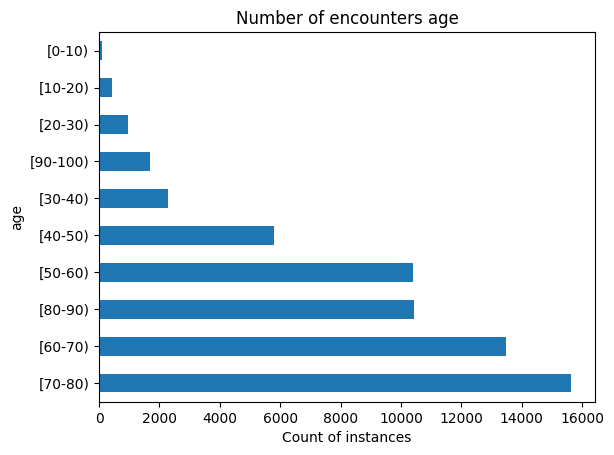

In [9]:
analyse_unique_values(dfr = df, column_name = 'age')

Age feature has no missing values.

### 5. What about the feature of **weight**?

No NAs identified in weight (count = 0)
weight
?            59285
[75-100)       827
[50-75)        520
[100-125)      376
[125-150)       89
[25-50)         57
[0-25)          27
[150-175)       23
[175-200)        5
>200             2
dtype: int64


weight
?            59285
[75-100)       827
[50-75)        520
[100-125)      376
[125-150)       89
[25-50)         57
[0-25)          27
[150-175)       23
[175-200)        5
>200             2
dtype: int64

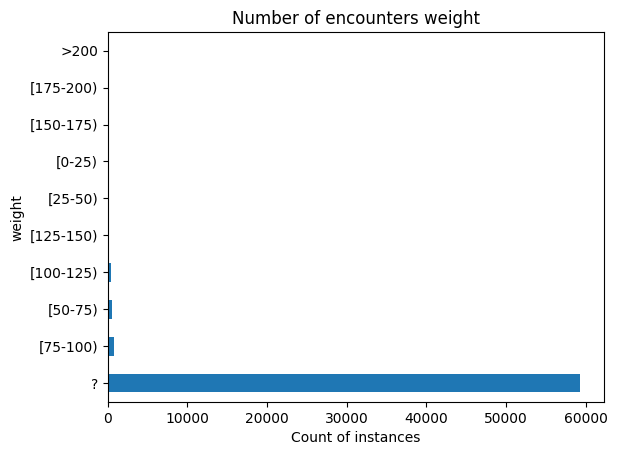

In [10]:
analyse_unique_values(df, 'weight')

This feature has many '?' values. We should consider adding this feature later on our model as it may be important for predicting the outcome. On the other hand the majority of the values are '?'.

### Additional analysis of the dataframes' numeric features is required.

In [11]:
numeric_feats_analysis = \
df.describe().drop( # dropping the numeric indexes
    columns = ['encounter_id',
              'admission_type_id',
              'admission_source_id',
              'discharge_disposition_id',
               'readmitted'
               ])
# print results as a dataframe
numeric_feats_analysis

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,61211.000000,61211.000000,61211.000000,61211.000000,61211.000000,61211.000000,61211.000000,61211.000000
mean,4.394276,43.153829,1.330022,15.992763,0.361210,0.191926,0.637042,7.421199
std,2.986187,19.655899,1.700112,8.108406,1.243993,0.789194,1.246116,1.934352
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,32.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,79.000000,42.000000,28.000000,13.000000,16.000000


There are no Nans or negative values in the numeric features above, meaning that we can transform them with no problem.
Specifically, we may use **MinMaxScaler** or **StandardScaler** (z-score) to transform these numeric features.

#### Histogram plots of numeric features & readmitted (barplot)

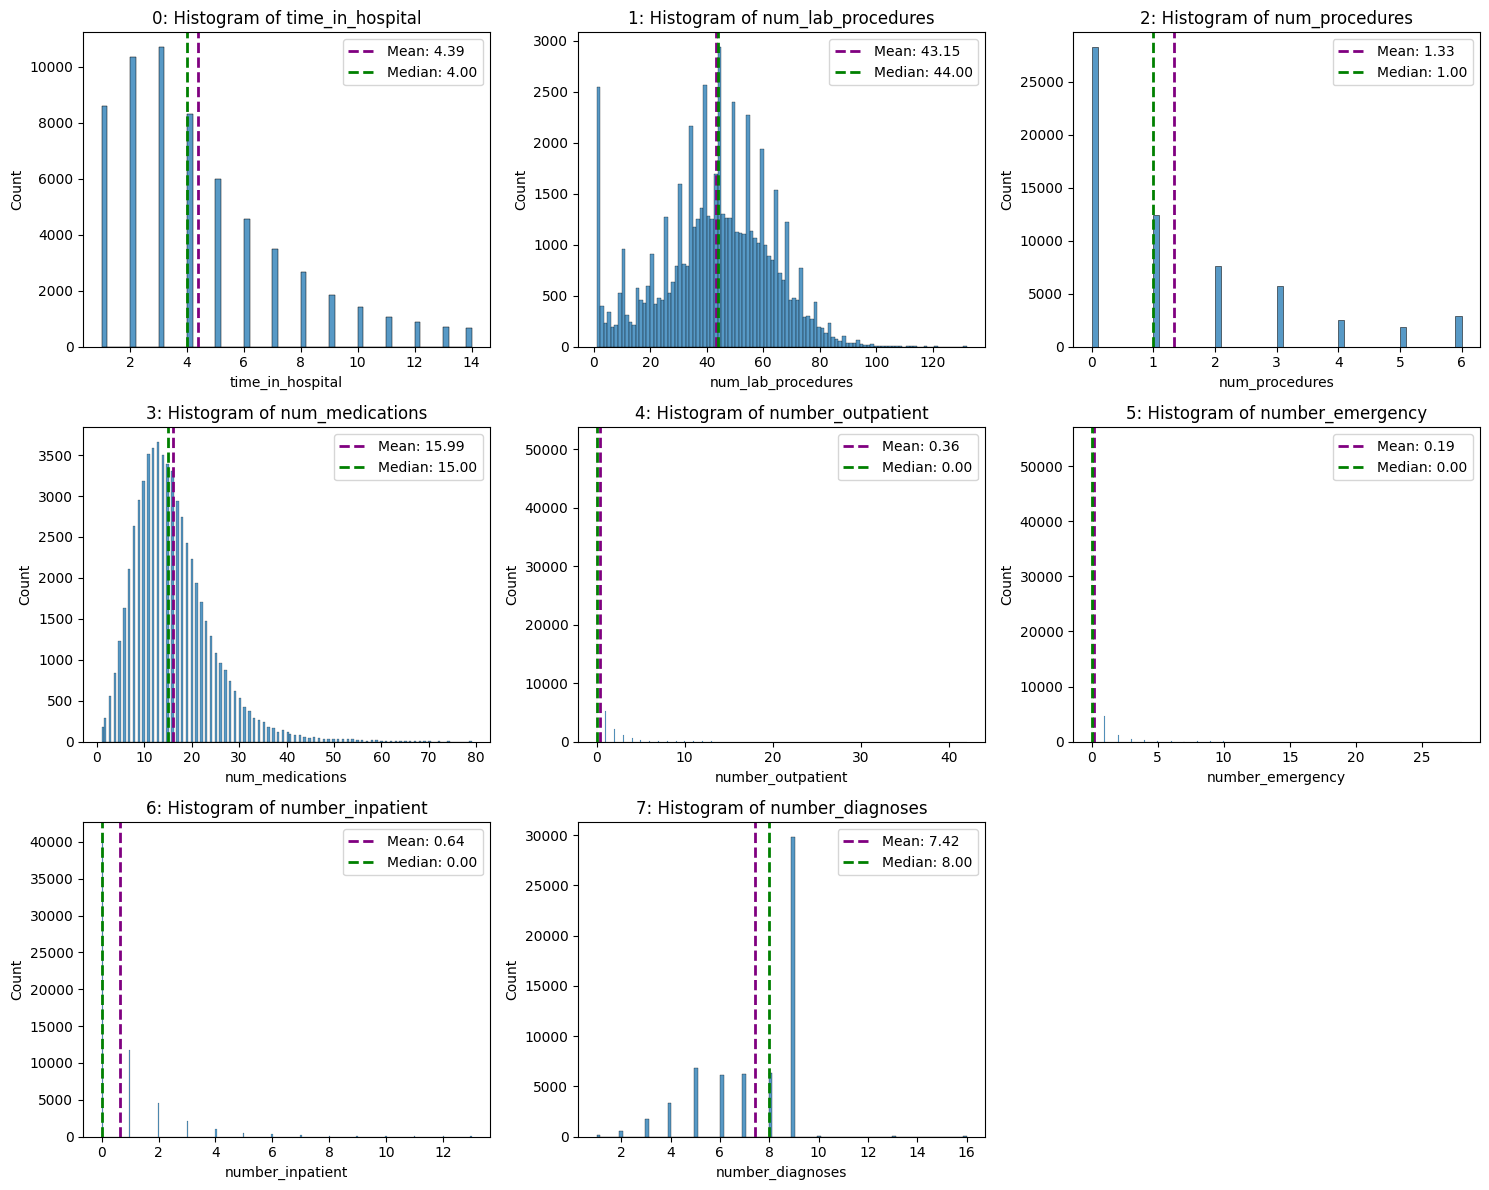

In [12]:
# also added to src.visualisations.viz_analysis.py
def plot_histograms(dfr,
                    numeric_features = None
                    ):
    if numeric_features is None:
        #automatically select all numeric features
        # as indicated by the dtypes
        numeric_features = dfr.select_dtypes(
            include = ['int64', 'float64']).columns.to_list()

    # numeric_feats = numeric_feats_analysis.columns.to_list()
    n_feats = len(numeric_features)

    # calculating the number of rows needed for 3 columns
    n_rows = int(np.ceil(n_feats / 3))

    # create subplots using a grid layout
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))

    # flatten the axes array for easy iteration
    axes = axes.flatten()
    # iterate over the chosen features and plot the histograms
    for i, column in enumerate(numeric_features):
        # calculate the mean and median of the feature
        mean_ = dfr[column].mean()
        median_ = dfr[column].median()
        axes[i].axvline(mean_, color='purple', linestyle='dashed',
                        linewidth=2, label=f'Mean: {mean_:.2f}')
        axes[i].axvline(median_, color='green', linestyle='dashed',
                        linewidth=2, label=f'Median: {median_:.2f}')

        sns.histplot(dfr[column], ax=axes[i])
        axes[i].set_title(f'{i}: Histogram of {column}')
        axes[i].legend()
    # Hide any unused subplots
    for j in range(n_feats, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


plot_histograms(df,
                numeric_feats_analysis.columns.to_list())


Do we need to log-transform some of the features?

I will standardize them with the following function.

In [13]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler

def transform_numeric(X, numerical_features,
                      remainder_behaviour = 'passthrough'):
    # initialize scaler for
    # numeric features transformations

    #The standard score of a sample x is calculated as:
    # z = (x - u) / s
    # where u is the mean of the training samples or zero if with_mean=False,
    # and s is the standard deviation of the training samples or one if with_std=False.
    numeric_scaler = StandardScaler()

    # Set up the column transformer
    # with appropriate transformers for each type of column
    transformer = make_column_transformer(
        (numeric_scaler, numerical_features),
        remainder= remainder_behaviour  # By default, unhandled columns will be passed through as is
    )

    # fit transformer on the training data
    transformer.fit(X)

    # transform the training data
    X_train_transformed = transformer.transform(X)

    # converting the transformed data (numpy) to a DataFrame
    # by also extracting the column names
    # also, I keep the indexes of the original data
    X_train_transformed_df = \
        pd.DataFrame(X_train_transformed,
                     columns = transformer.get_feature_names_out(),
                     index = X.index)

    # return the transformed data and the transformer
    return X_train_transformed_df, transformer

In [14]:
df_transformed_temp = transform_numeric(
    X = df,
    numerical_features = numeric_feats_analysis.columns.to_list(),
    remainder_behaviour = 'drop'
)

In [15]:
df_transformed_temp[0]

,standardscaler__time_in_hospital,standardscaler__num_lab_procedures,standardscaler__num_procedures,standardscaler__num_medications,standardscaler__number_outpatient,standardscaler__number_emergency,standardscaler__number_inpatient,standardscaler__number_diagnoses
0,-0.466912,0.806186,-0.782321,0.247552,-0.290365,-0.243195,-0.511227,0.816198
1,-0.801790,-1.635849,2.158686,-0.369097,1.317374,-0.243195,0.291274,-0.734722
2,-0.801790,0.043050,-0.194120,0.000893,-0.290365,-0.243195,-0.511227,-0.217748
3,0.202844,1.518446,-0.782321,-0.492427,-0.290365,-0.243195,-0.511227,0.299225
4,2.546990,-0.516583,0.982283,0.247552,-0.290365,-0.243195,-0.511227,0.299225
...,...,...,...,...,...,...,...,...
61206,0.537722,0.093925,-0.194120,1.110861,2.121243,1.023931,1.093774,0.816198
61207,-0.466912,0.399180,-0.782321,0.000893,-0.290365,-0.243195,-0.511227,0.816198
61208,0.202844,-0.516583,0.982283,0.247552,-0.290365,-0.243195,0.291274,0.816198
61209,-1.136668,0.500931,-0.782321,-0.862416,0.513504,-0.243195,-0.511227,2.884090


#### Histogram plots of numeric features & readmitted (barplot) after transformation

In this way I can see the distribution of the numeric features after Standard Scale transformation.
The minimum value of the transformed features (overall) is less than -3.0 and the maximum value more than is 35.

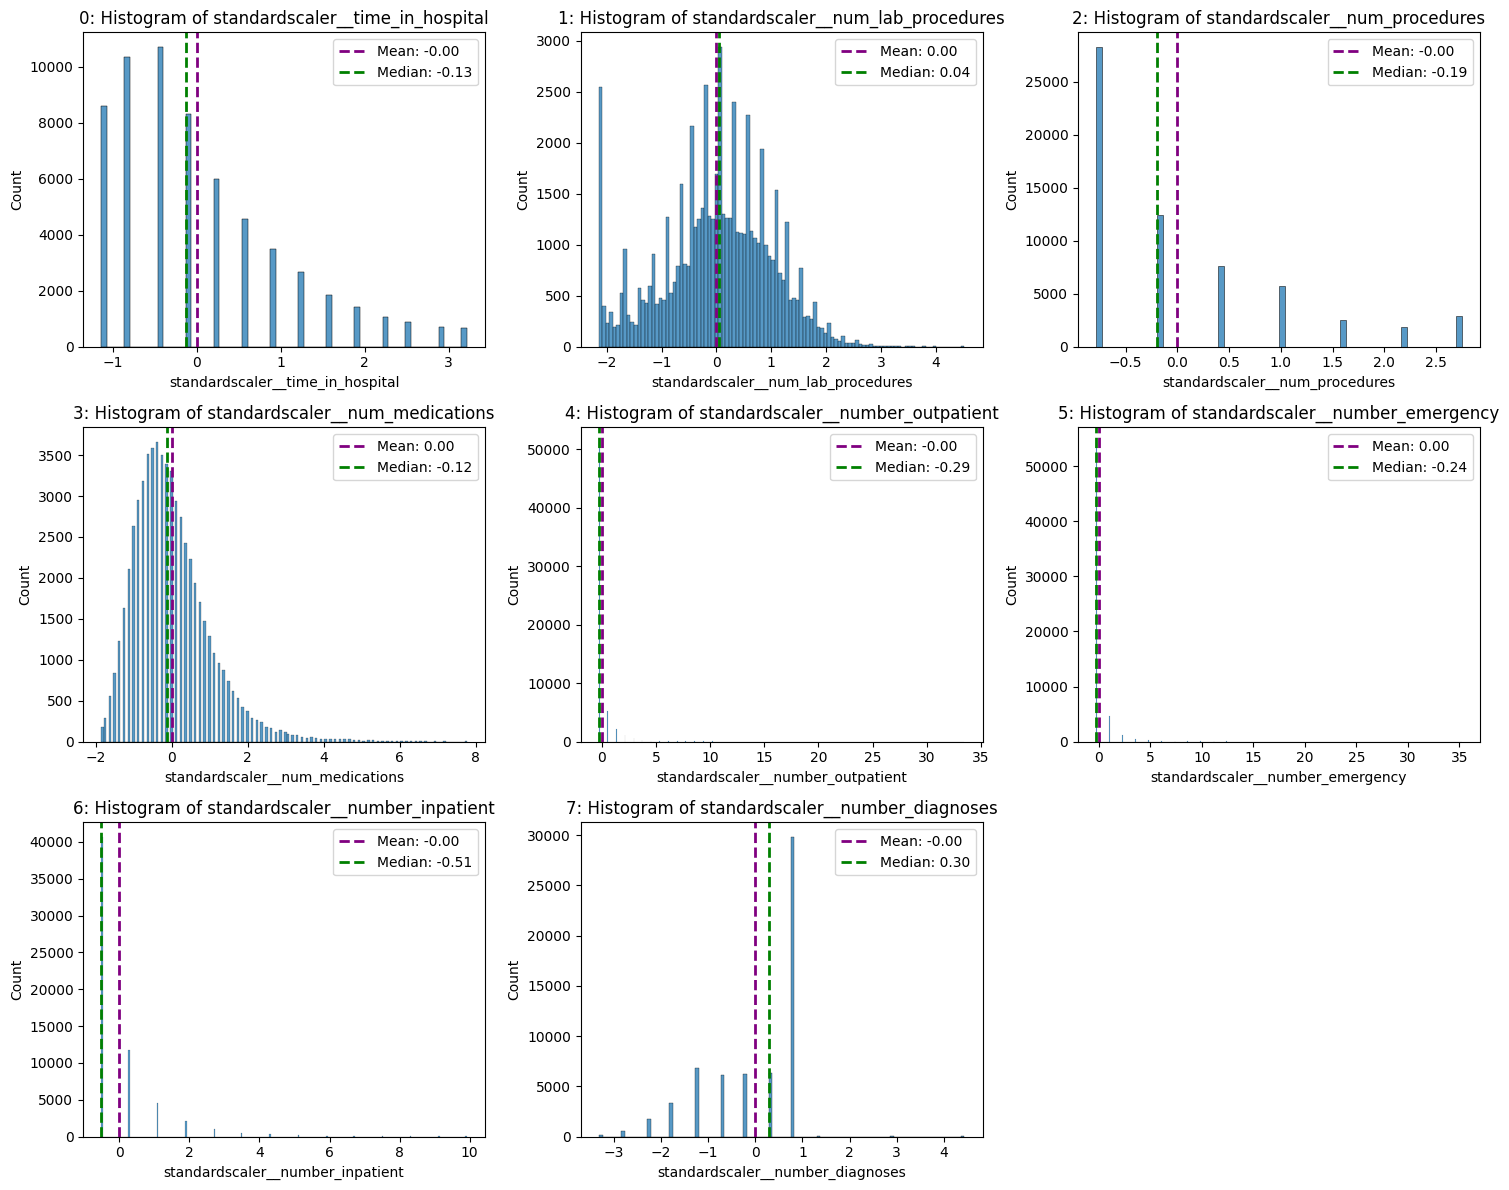

In [16]:
plot_histograms(df_transformed_temp[0])

#### What is the correlation between the numeric features and the target variable?

##### Using Spearman method

<Axes: title={'center': 'Correlation Heatmap'}>

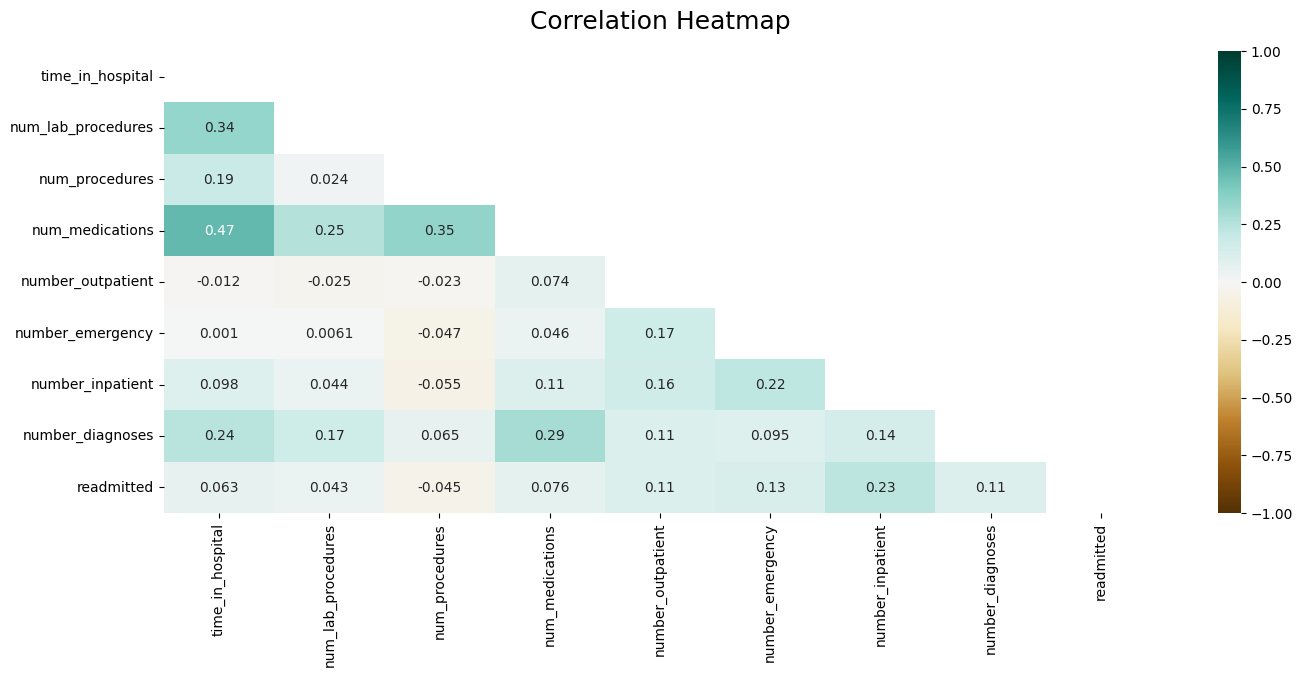

In [17]:
# select the numeric features + readmitted feature
numeric_feats = numeric_feats_analysis.columns.to_list()
numeric_feats.append('readmitted')
# plot the correlation matrix
plot_triangular_heatmap(heatmap_df = df[numeric_feats],
                        method = 'spearman')

Time in hospital and number of medications are correlated but not strongly. We do not have any strong correlations between the numeric features indicating that we do not have any strong indication of collinearity between the features above.

Additional correlation plot below:

<Axes: title={'center': 'Correlation with readmitted'}, ylabel='Variables'>

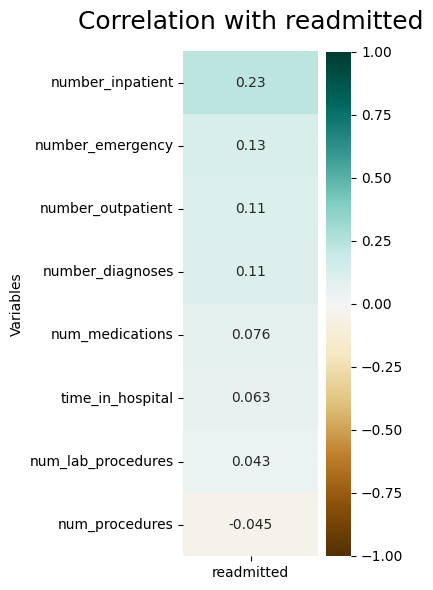

In [18]:
plot_correlation_column_heatmap(
    df[numeric_feats],
    chosen_variable='readmitted',
    method='spearman',
    encode_categoricals= True,
    sort_values= True,
    exclude_self= True
)

Below, a longer column plot is demonstrated for all the variables included in the dataframe vs. readmitted feature (target variable):

<Axes: title={'center': 'Correlation with readmitted'}, ylabel='Variables'>

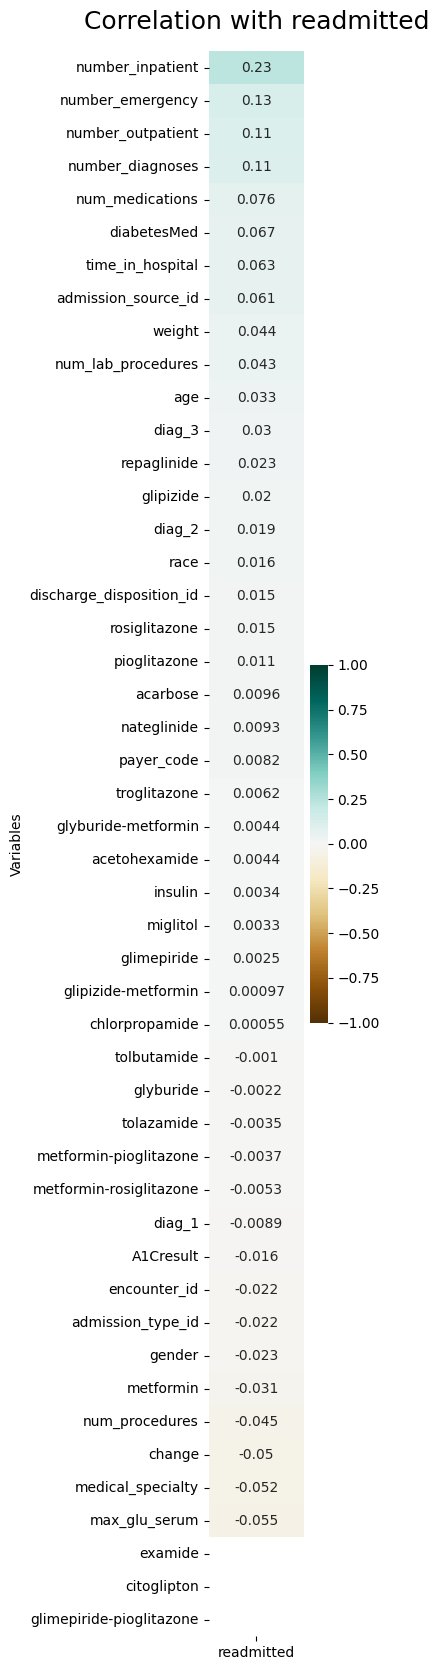

In [19]:
plot_correlation_column_heatmap(
    df,
    chosen_variable='readmitted',
    method='spearman',
    encode_categoricals= True,
    sort_values= True,
    exclude_self= True
)

Overall, there are no strong correlations between some of the numeric features and the target variable. In other words, models like the classic logistic regression may not perform well on this dataset. We may want to consider using more complex models or feature engineering techniques to improve the predictive performance.

#### Additional Stacked Bar Plots
 ##### Analysis of the Medication Features vs. Readmitted

In [20]:
# filter the dataframe to include only the selected features
selected_df = pd.concat(
    [df.loc[:, 'metformin':'metformin-pioglitazone'],
        df[['readmitted']]
    ],axis=1)

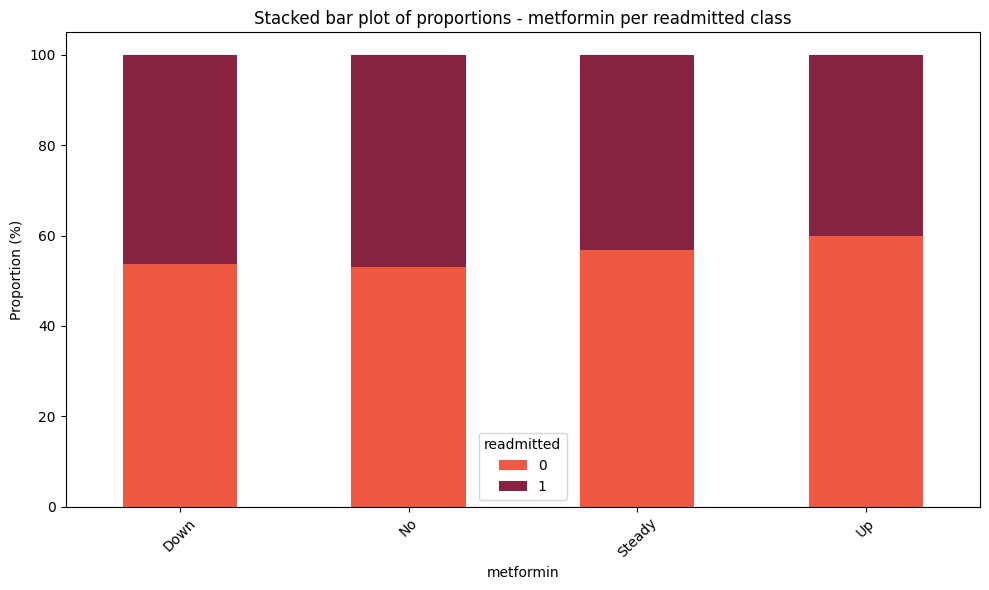

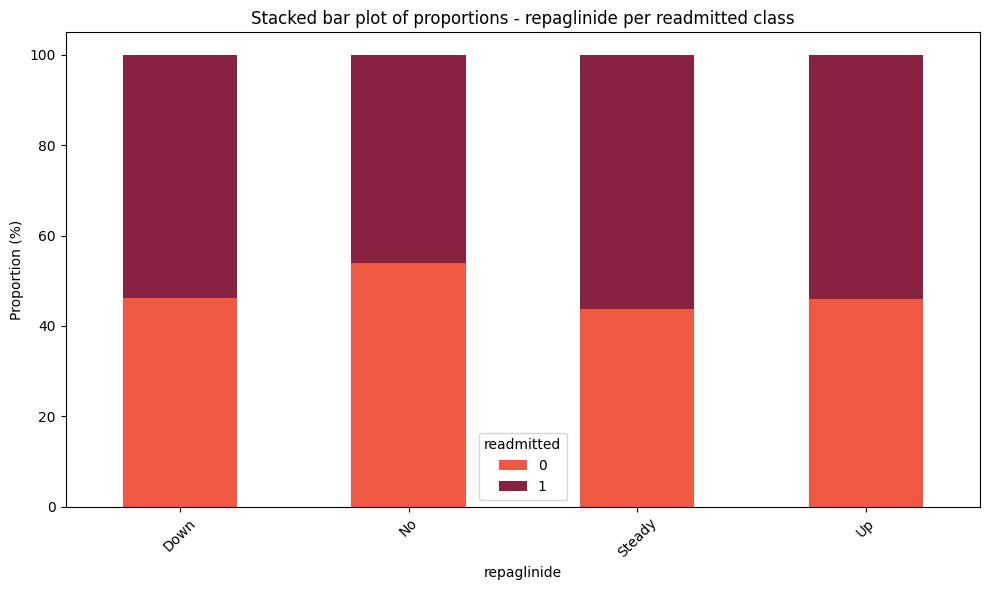

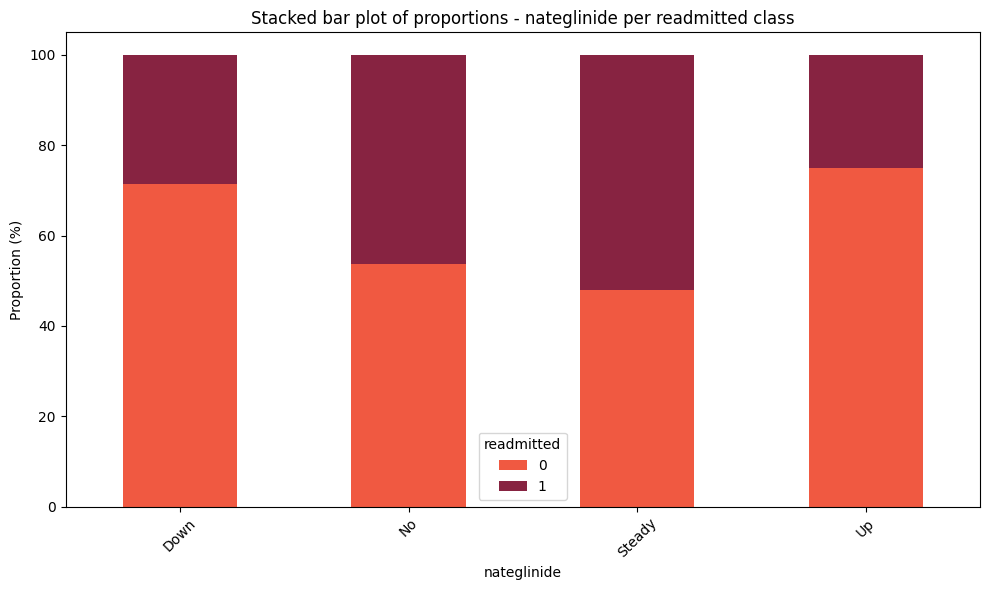

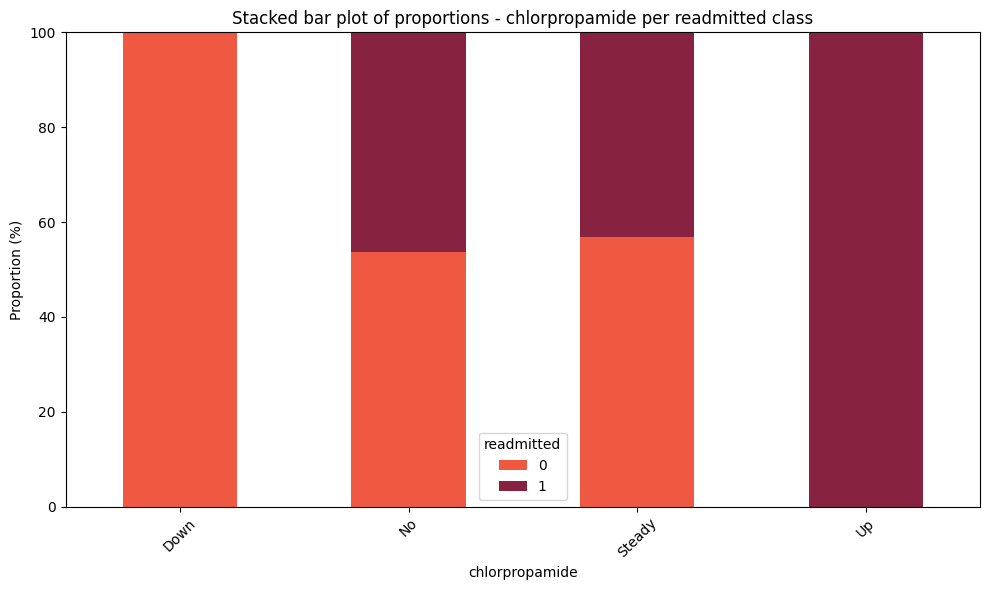

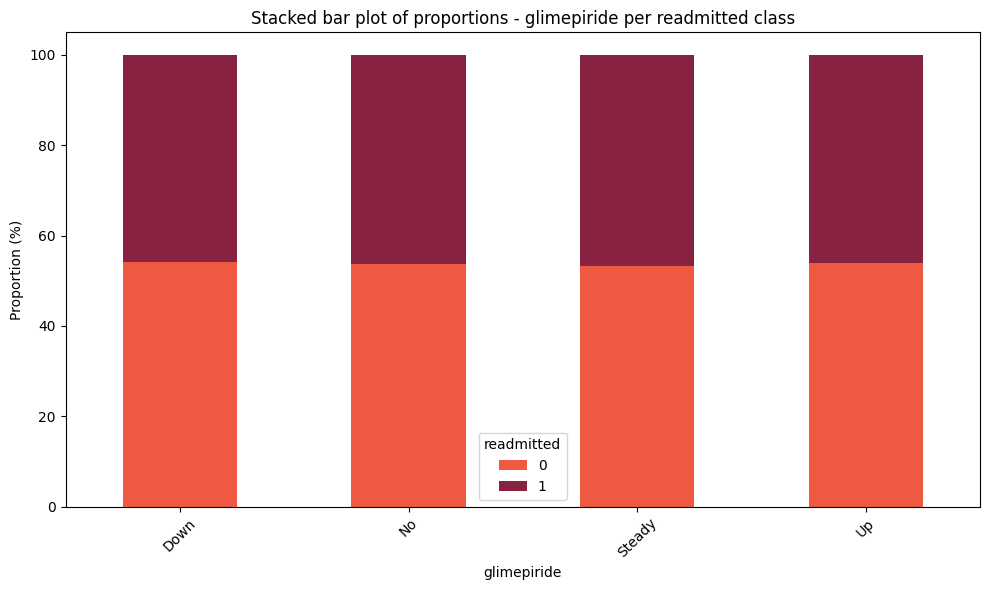

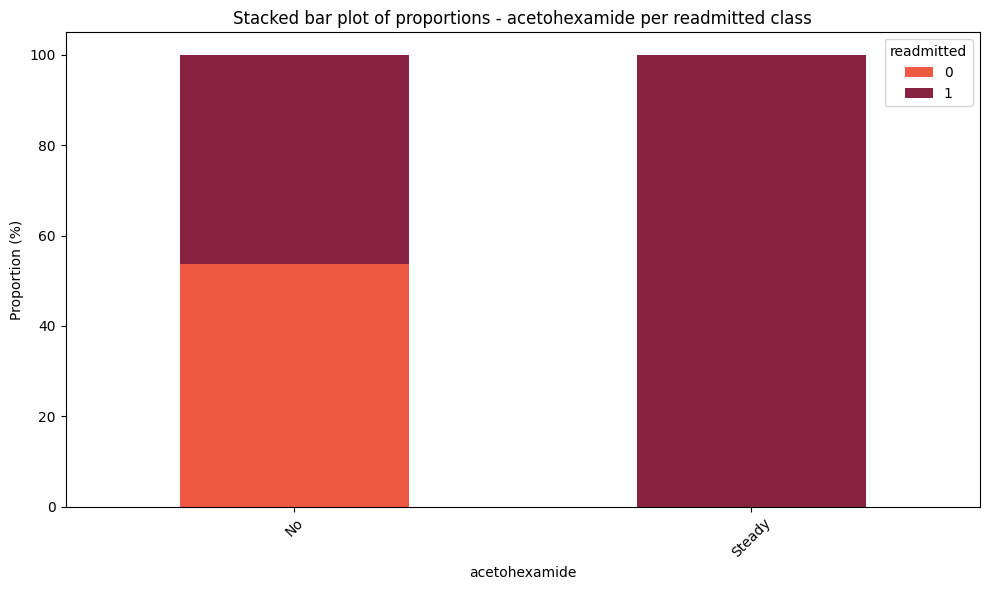

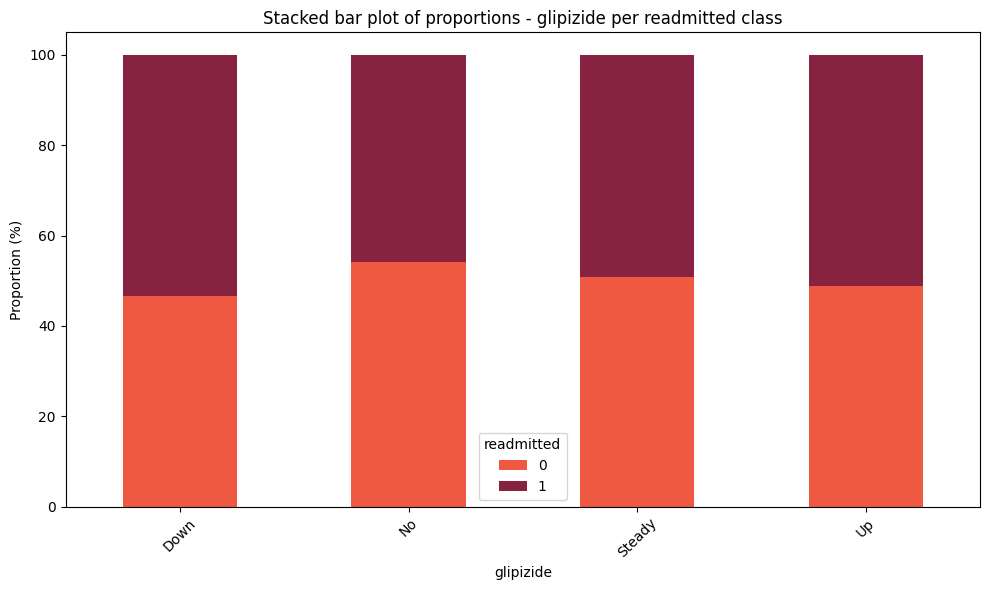

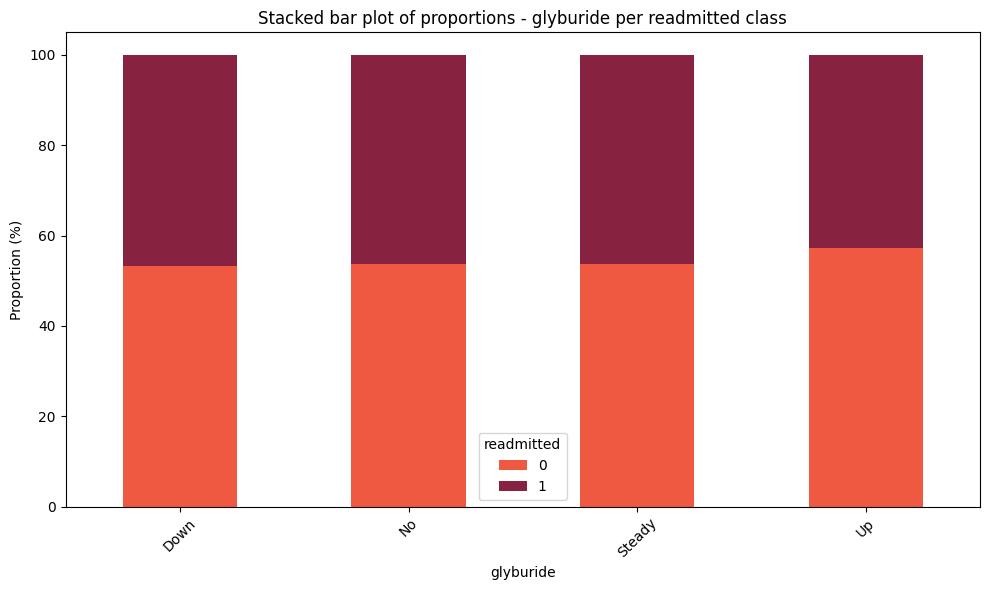

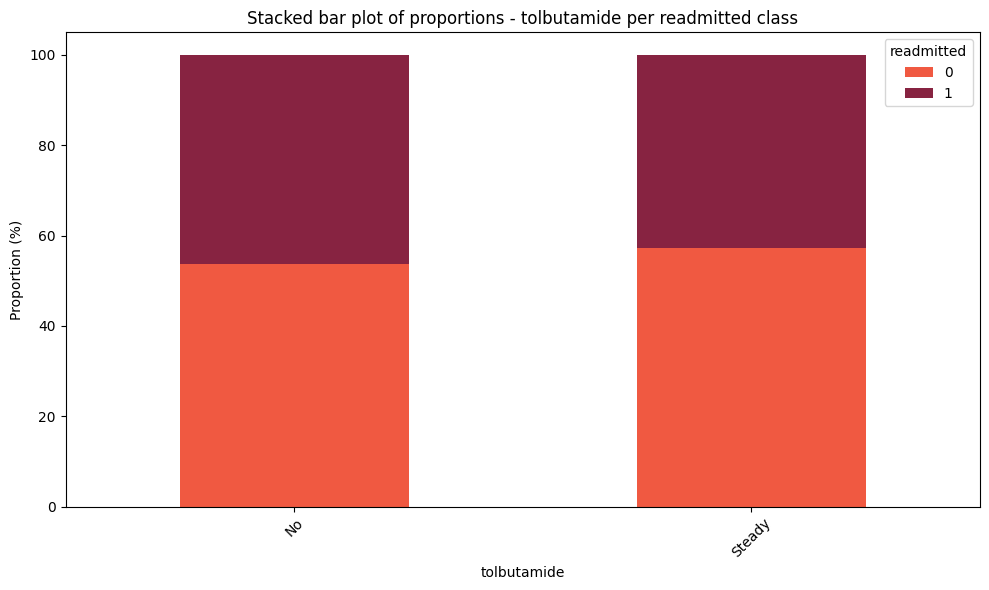

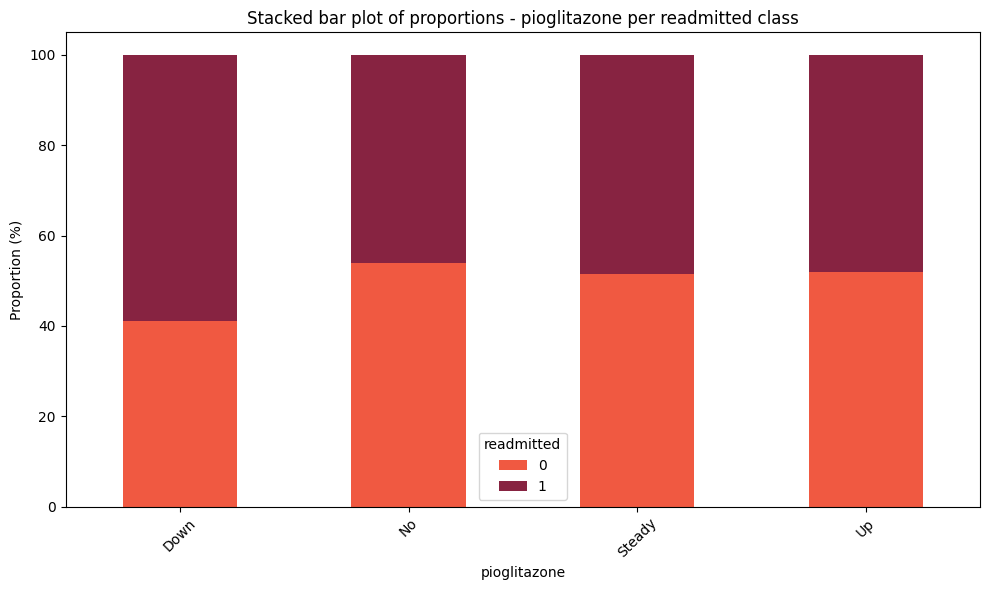

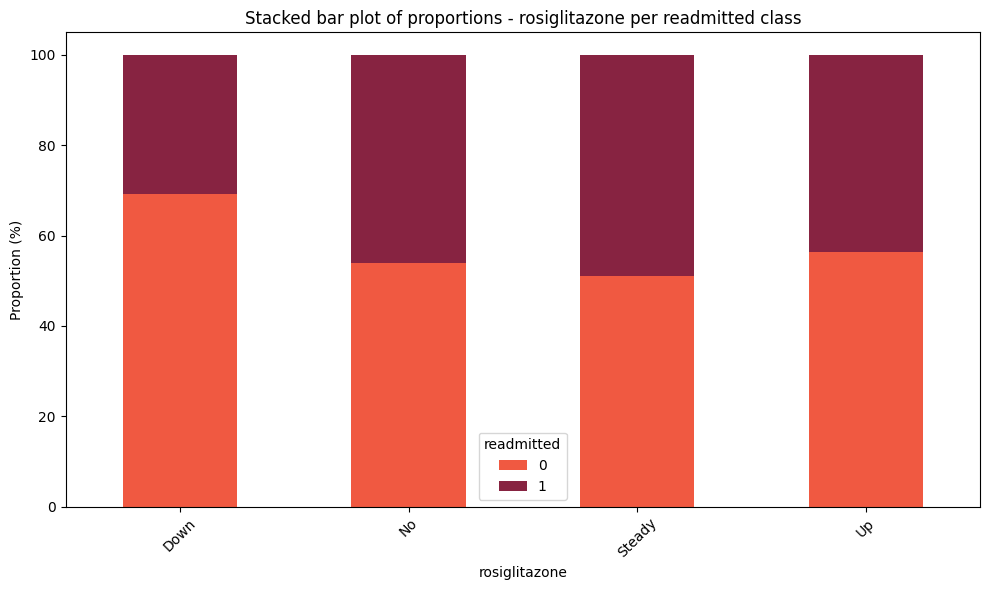

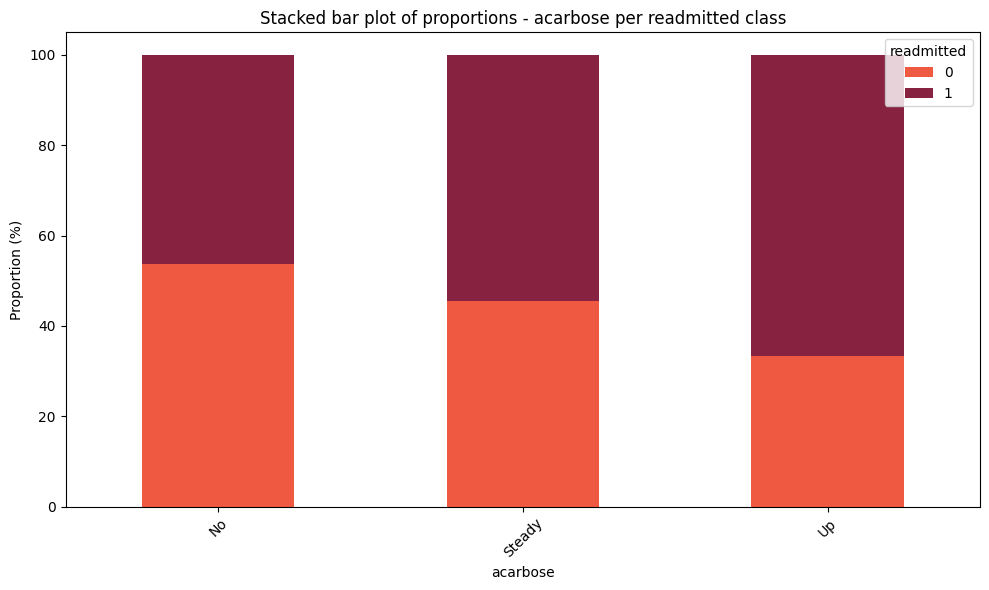

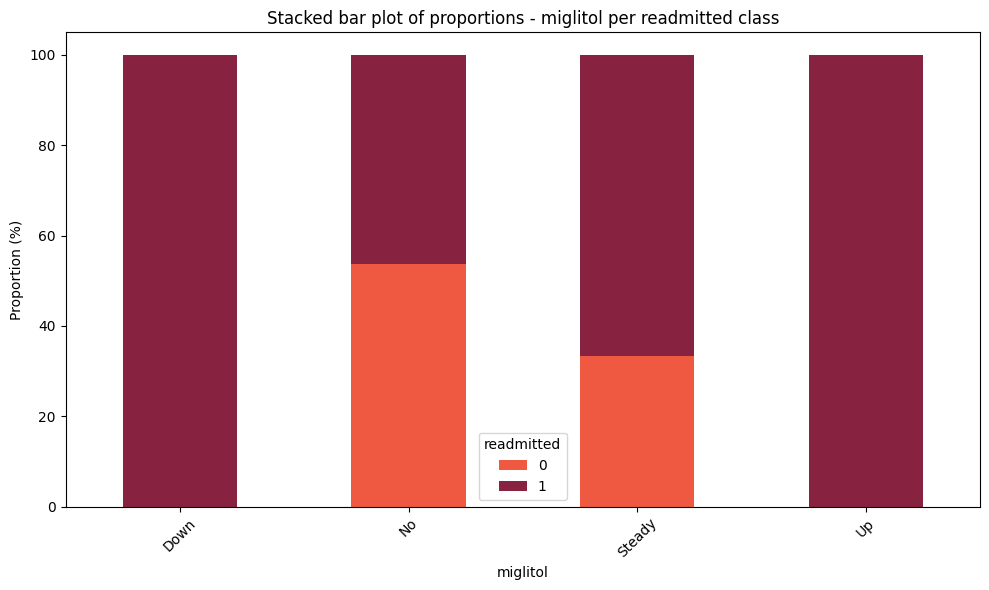

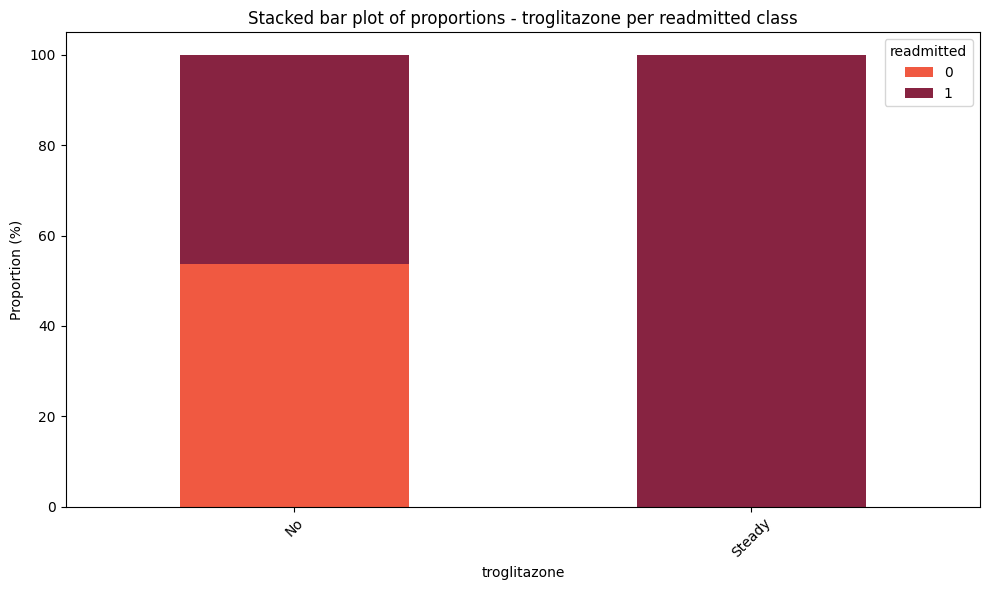

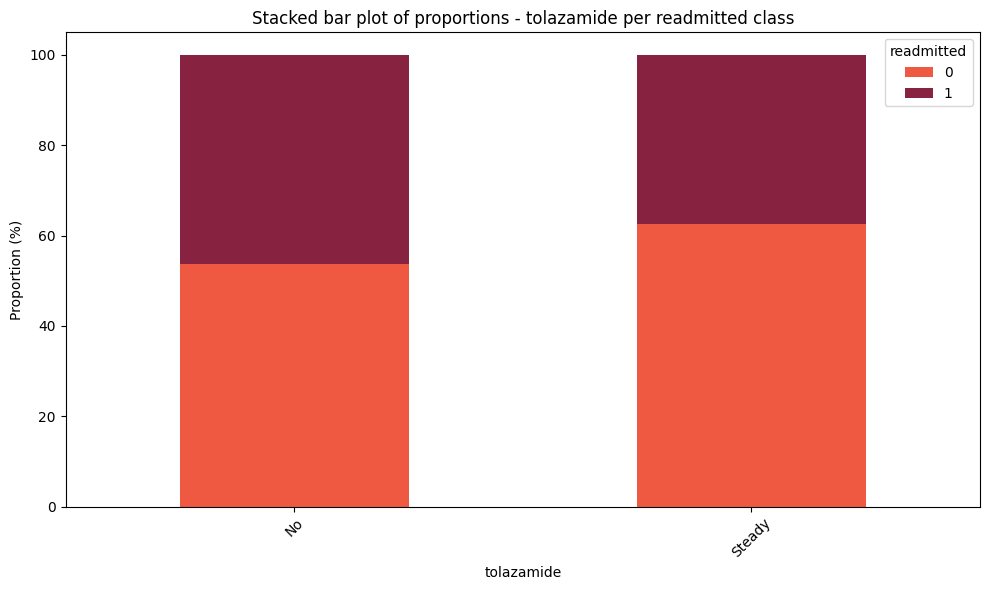

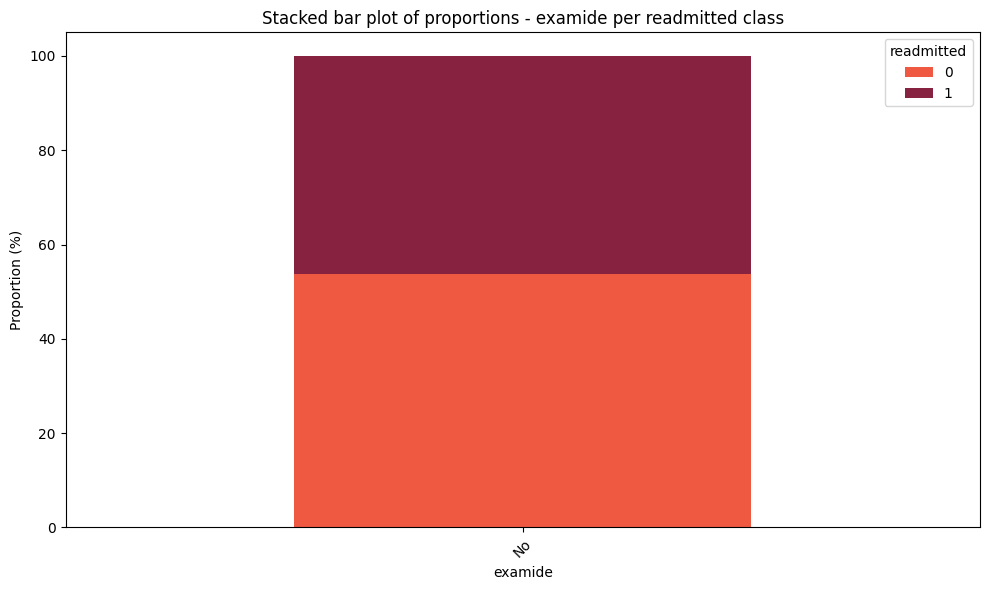

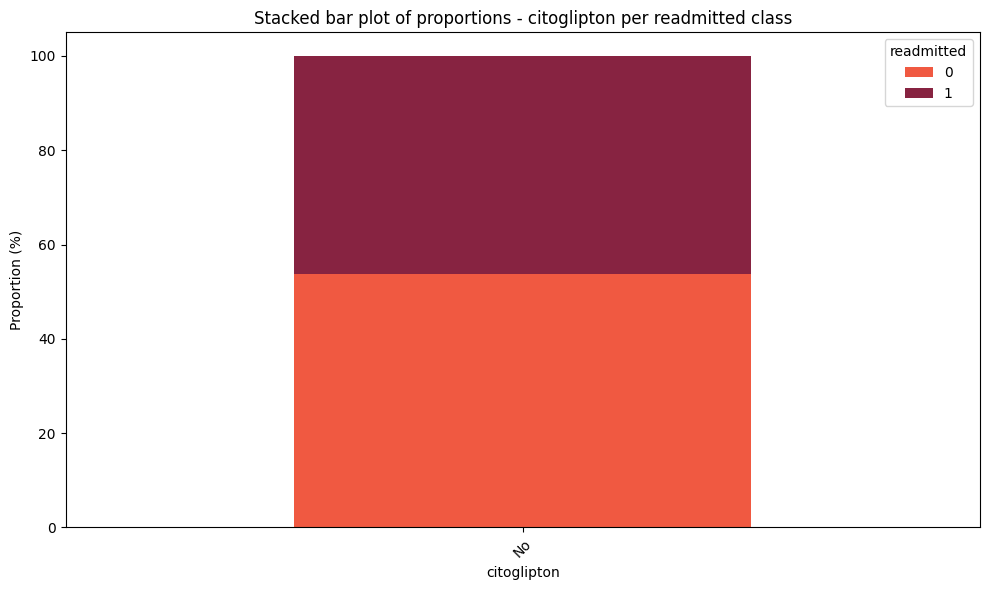

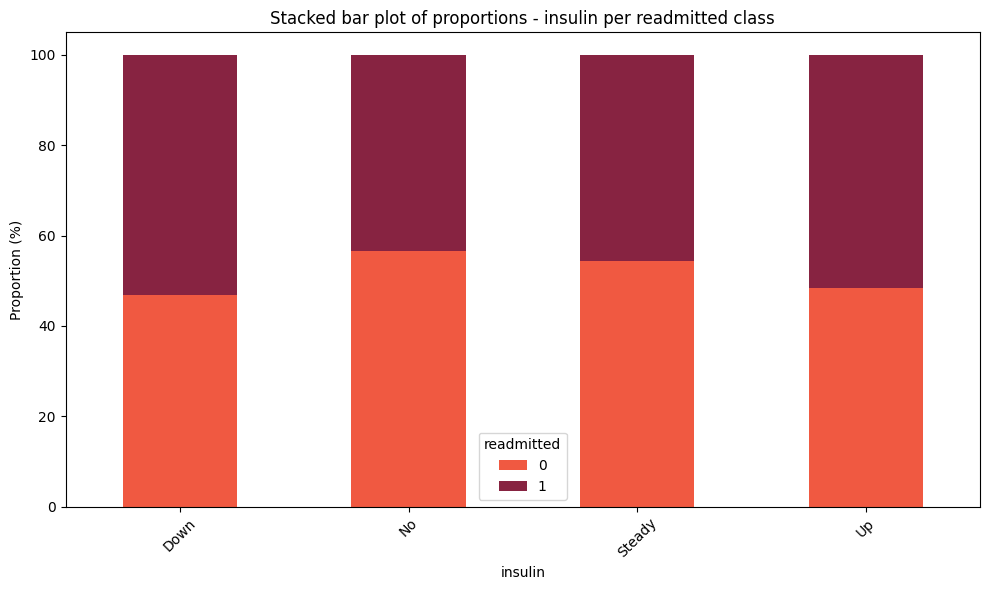

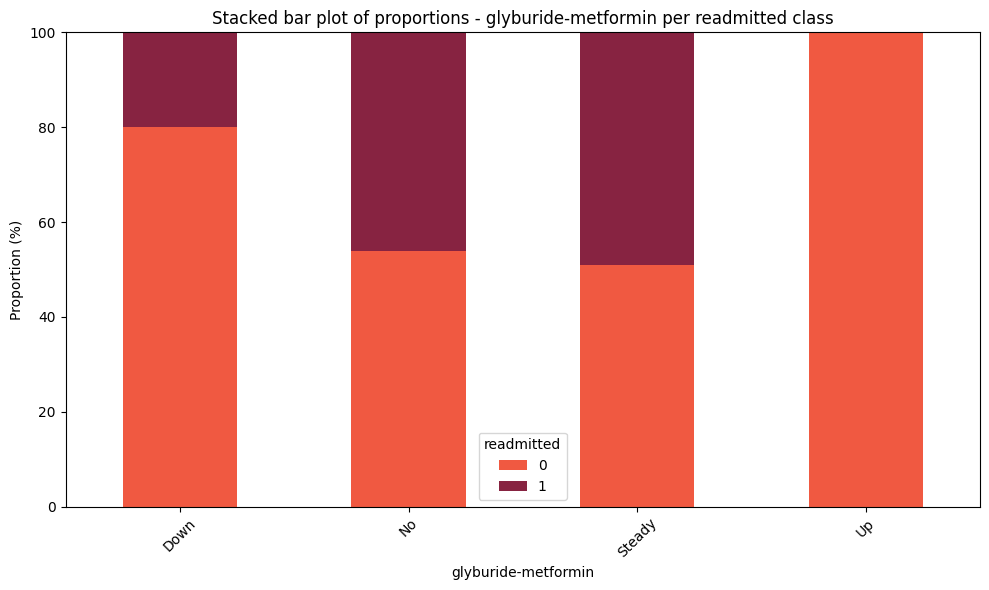

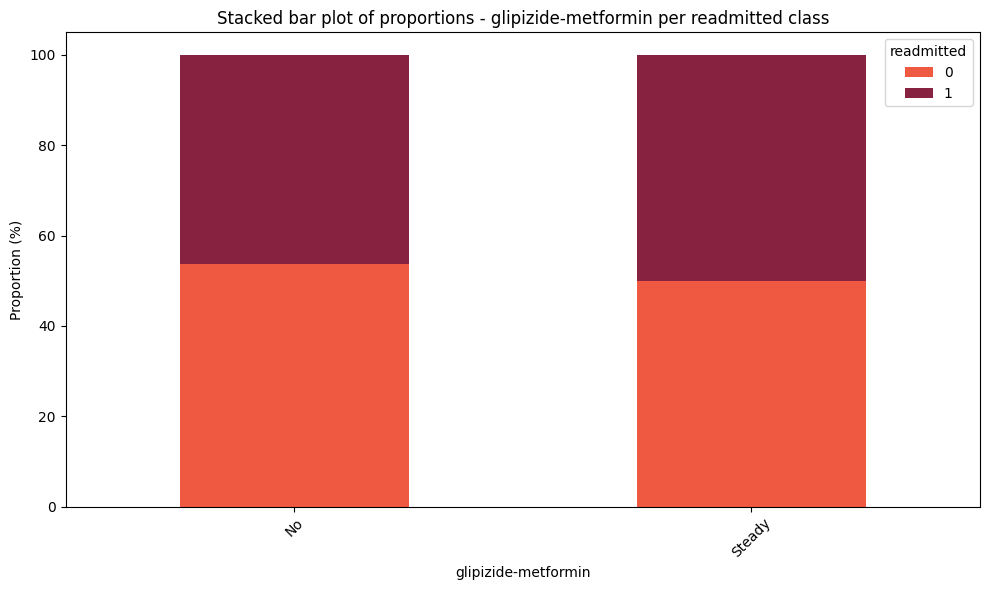

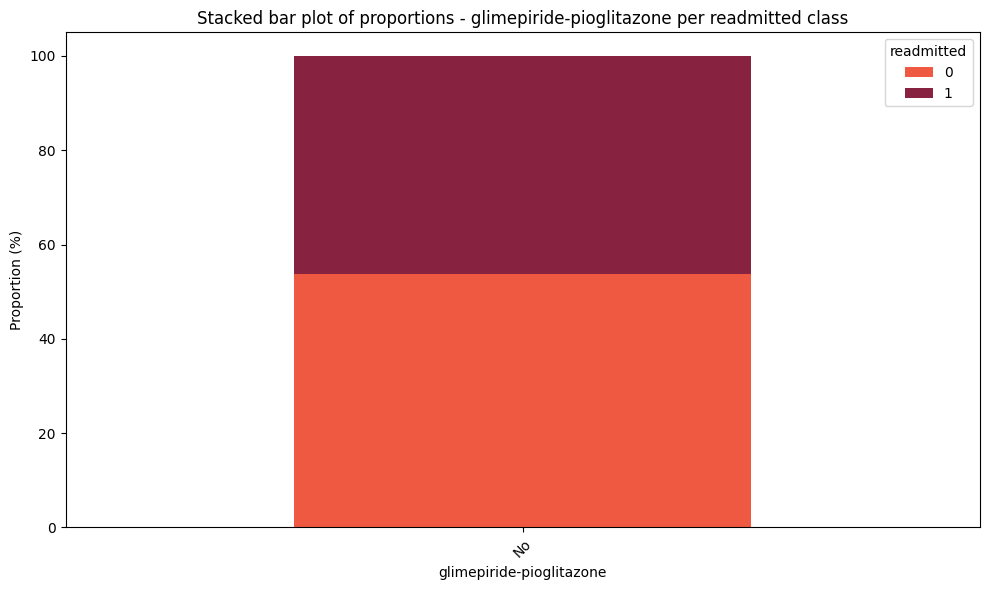

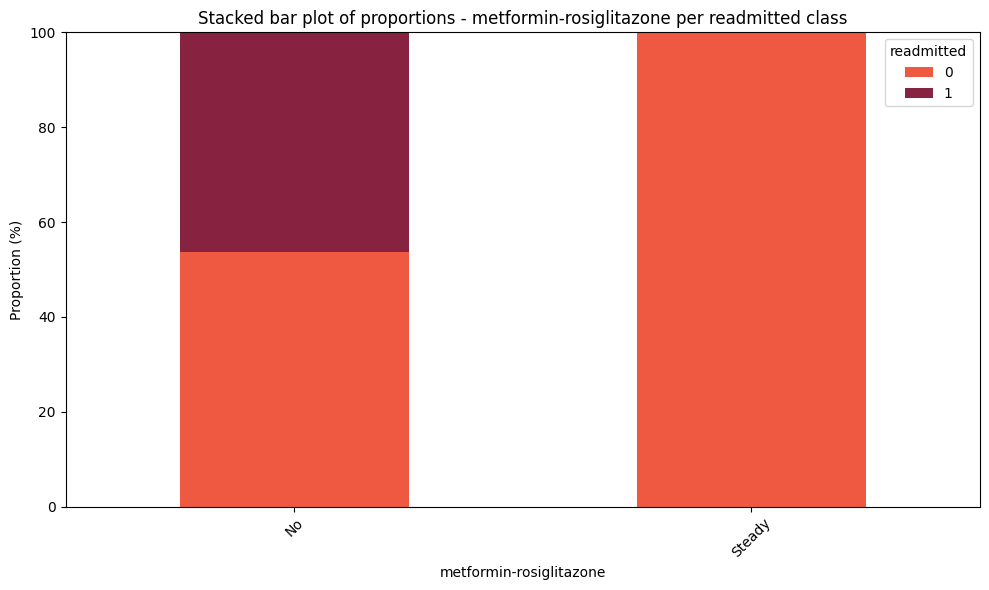

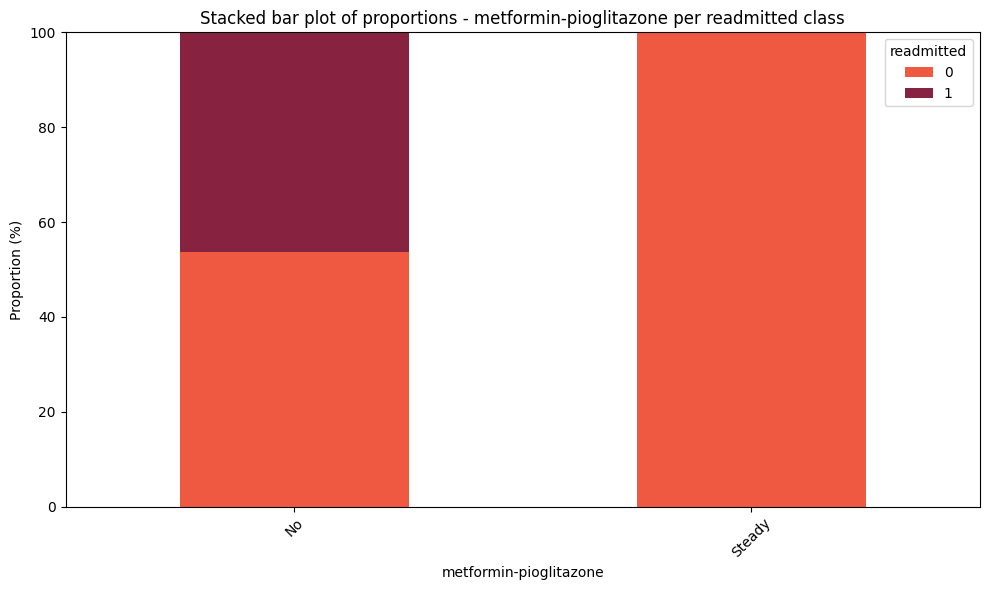

In [22]:
# choose the features to be plotted
features_list = df.loc[:, 'metformin':'metformin-pioglitazone'].columns.to_list()
# apply the function
plot_categorical_stacked(selected_df,
                             target='readmitted',
                             excluded_feats= None,# example: ['name_feat_1', 'name_feat_2']
                             choose_specific_feats= features_list,# example: ['name_feat_1', 'name_feat_2']
                             percentage= True,
                             color_map=['#F05941', '#BE3144', '#872341'])